# gradpulse, a 5-minute intro: optimize a CZ

Optimize a CZ on a representative parametric-coupler transmon pair, then
inspect and plot the result. Needs `pip install gradpulse[viz]`.

In [1]:
import gradpulse as gp
from gradpulse import viz

# One call: representative device, sensible defaults.
r = gp.optimize_cz(n_seeds=4, iterations=200)
print('process fidelity to CZ:', r['best_fidelity'])
print('converged:', r['converged'], ' final grad norm:', r['final_grad_norm'])
print('rolled-back non-finite steps:', r['n_nonfinite_steps'])

<string>:21: RepresentativeDefaultsWarning: ParametricCouplerProfile is using representative published-typical device parameters (T1/T2, frequencies, anharmonicity), NOT a measurement of your device -- the resulting fidelity is a design-tool number, not a hardware prediction. Load a real calibration via from_braket_calibration / from_ibm_backend / from_calibration before quoting a fidelity for a specific qubit. Silence: warnings.filterwarnings('ignore', category=gradpulse.RepresentativeDefaultsWarning).


 [gradpulse] Starting parametric-CZ GRAPE (4 seeds, 150 slices @ 1.0 ns = 150.0 ns gate, 200 iters, loss=F_proc, lr=0.0100/cosine(min=0.05), drag_order=0)...


    Step 0000 | Max Fid: 0.9196270  | Mean: 0.8539099  | lr: 0.00100


    Step 0025 | Max Fid: 0.9844630  | Mean: 0.9773048  | lr: 0.00985


    Step 0050 | Max Fid: 0.9894609  | Mean: 0.9883482  | lr: 0.00900


...

    Step 0125 | Max Fid: 0.9900895  | Mean: 0.9897363  | lr: 0.00371


    Step 0150 | Max Fid: 0.9901208  | Mean: 0.9897981  | lr: 0.00203


    Step 0175 | Max Fid: 0.9901332  | Mean: 0.9898238  | lr: 0.00090


    Step 0199 | Max Fid: 0.9901420  | Mean: 0.9898376  | lr: 0.00050

 [gradpulse] Adam plateau: F_proc=0.9901434. Switching to L-BFGS polish (50 iters)...


    L-BFGS:  F_proc=0.9902831  (+0.00014)
process fidelity to CZ: 0.9902830719947815
converged: False  final grad norm: 0.002862336579710245
rolled-back non-finite steps: 0


## The optimized pulse
Channels are q1 drive, q2 drive, and coupler activation.

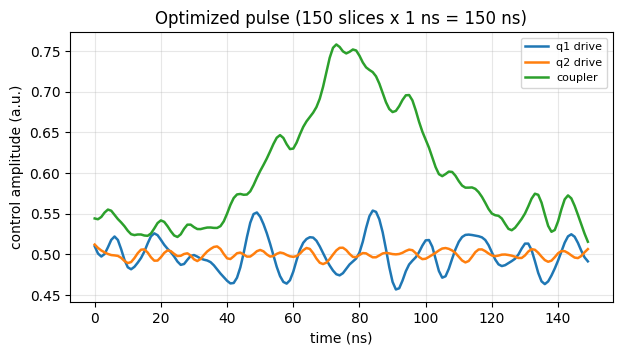

In [2]:
viz.plot_pulse(r);

## Convergence
Infidelity (1 - F) vs iteration, log axis.

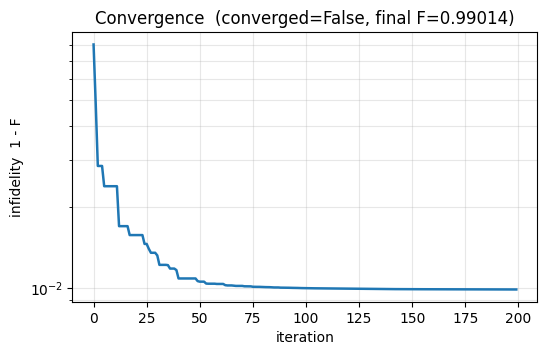

In [3]:
viz.plot_convergence(r);

## Error budget
Split the infidelity into control/leakage vs the decoherence floor
(a forward-pass analysis on the optimized pulse).

{'F_proc': 0.9902830719947815,
 'F_avg': 0.9922264575958252,
 'F_proc_closed': 0.9995354413986206,
 'r_total': 0.007773542404174827,
 'r_control_leakage': 0.0003716468811034712,
 'r_decoherence': 0.007401895523071356,
 'leakage': 0.0003771185874938965,
 'unitarity': 0.9803311436092618,
 'r_incoherent_unitarity': 0.007412450764080092,
 'coherent_excess': 0.00036109164009473504}

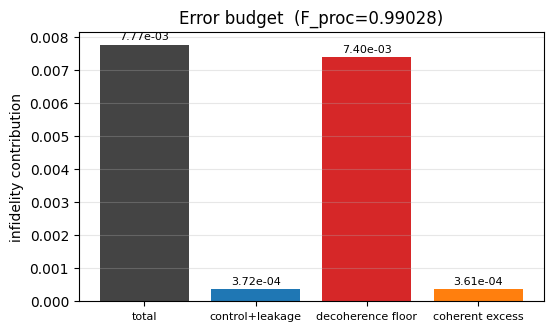

In [4]:
opt = r['optimizer']
budget = opt.error_budget(r['best_raw_param'])
viz.plot_error_budget(budget)
budget

## Robustness to miscalibration
Fidelity vs amplitude- and drive-frequency error -- the calibration
tolerances an experimentalist asks about first.

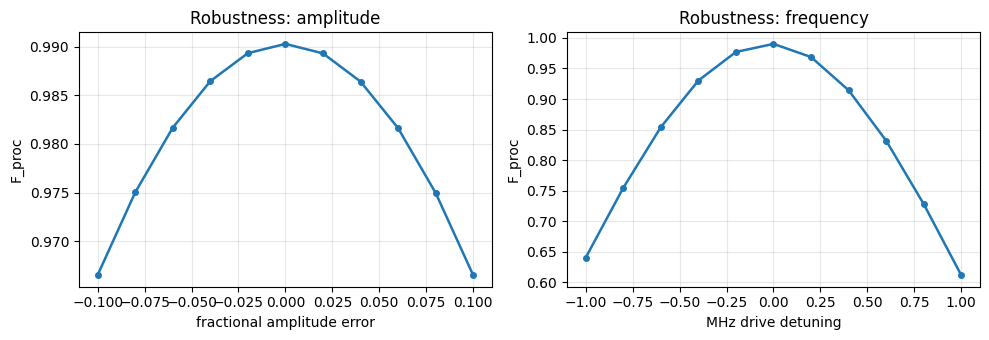

In [5]:
sweep = opt.robustness_sweep(r['best_raw_param'])
viz.plot_robustness(sweep);

## Next
- iSWAP: `gp.optimize_iswap()`
- A real device calibration: see `02_real_device.ipynb`
- **Validation on a live QPU**: see `03_hardware_validation.ipynb`, gradpulse's coherence floor vs the *measured* CZ error across all 160 Rigetti Cepheus pairs.
- Other architectures: `CrossResonanceZXOptimizer`, `MultiQubitOptimizer`
- Independent QuTiP cross-check: `python -m gradpulse.validate --pulse <pulse.json>`

### Going further
- **Band-limited (CRAB) optimization**, `opt.optimize_spectral(f_max_mhz=80)`: band-limited *by construction*, ~6× fewer parameters than per-slice (and the reported `out_of_band_fraction` measures it).
- **Analytic robustness (no Monte-Carlo)**, `opt.filter_function_fidelity(r['best_raw_param'], sigma_mhz=0.3, alpha=1.0)`: dephasing sensitivity to a 1/f^α noise PSD; overlay a measured S(f) on `opt.filter_function(...)`.
- **Complete I/Q + vendor-neutral export**, `opt.iq_waveform(r['best_raw_param'])` (in-phase + DRAG quadrature) → `gradpulse.openpulse_export.to_openpulse_program(...)` (OpenQASM 3 / OpenPulse 3.0).
- **Simultaneous gates**, `MultiQubitOptimizer(target_gate=['cz','cz'], target_qubits=[(0,1),(2,3)])`: parallel gates under one shared crosstalk budget.
- **Echoed cross-resonance**, `CrossResonanceZXOptimizer(..., echo=True)`: the Xπ echo that turns the always-on ZZ into a removable IZ.
- **Tunable coupler in the loop**, `gp.coupler_in_loop_cz(...)`: model the coupler explicitly (from a pair profile) and read the coupler-leakage budget the eliminated-pair model has none of.
- **Benchmark vs qutip-qtrl**, `gradpulse.benchmark.run_benchmark('cnot')`: same optimum, same optimizer class, head-to-head wall-clock.